In [1]:
import sys
import os

import numpy as np
from certifi import where
from fontTools.misc.cython import returns
from matplotlib import pyplot as plt
from sqlalchemy.dialects.mssql.information_schema import columns

sys.path.append(os.path.abspath(".."))

import importlib
import pandas as pd

import volpy_func_lib as vp
import load_clean_lib
import table_lib
import vol_strat_lib as vs
import volpy_func_ticker_lib as vtp

importlib.reload(vp)
importlib.reload(load_clean_lib)
importlib.reload(table_lib)
importlib.reload(vs)
importlib.reload(vtp)

os.makedirs("figures/Analysis/Period", exist_ok=True)

In [2]:
sum_df = vtp.concat_ticker_datasets(vp.All_tickers, df_name="sum1")

Skipped 2/237 tickers: ['RUT', 'INDU']


In [3]:
df = sum_df[sum_df["ticker"].isin(vp.Liquid_tickers)].copy()
name = "Liquid"

# table_lib.vol_period_analysis(df, "Liquid")

# Quantile

In [51]:
df = sum_df
df = df[df["ticker"] == "SPX"]

# 1) Compute the 30th and 70th percentiles of SW_0_30 using only SPX
spx_mask = df['ticker'] == 'SPX'
q30, q70 = df.loc[spx_mask, 'SW_0_30'].quantile([0.3, 0.7])

# 2) Build a small DataFrame of SPX’s SW_0_30 by date
spx_sw = (
    df[spx_mask]
    .loc[:, ['date', 'SW_0_30']]
    .drop_duplicates()
    .set_index('date')
)

# 3) Assign periods to SPX dates
spx_sw['period'] = pd.cut(
    spx_sw['SW_0_30'],
    bins=[-np.inf, q30, q70, np.inf],
    labels=[3, 2, 1]
).astype(int)

spx_sw = (
    spx_sw
    .reset_index()  # bring date back as column
    .merge(df[['date', 'RV']], on='date', how='left')
    .set_index('date')
)

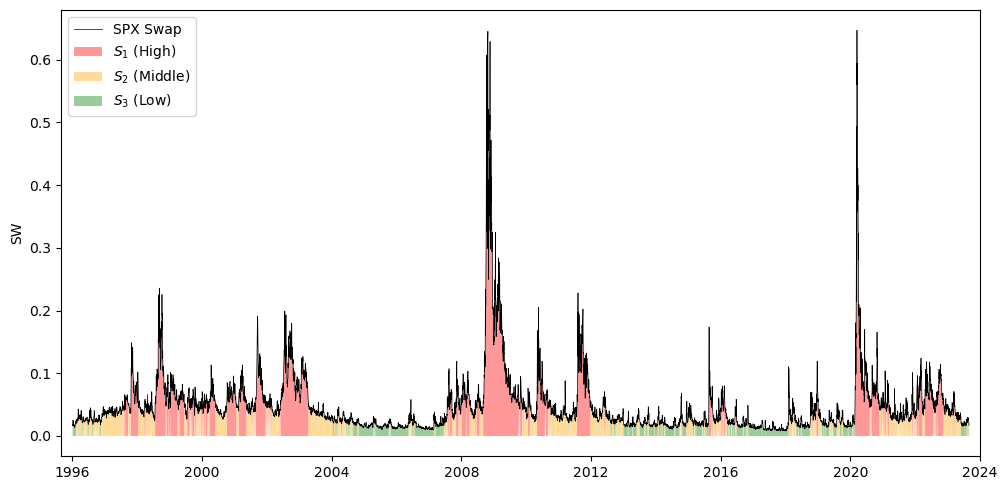

In [52]:
import matplotlib.pyplot as plt

expon = 1

# name map for periods
period_names = {1: r"$S_1$ (High)", 2: r"$S_2$ (Middle)", 3: r"$S_3$ (Low)"}
# colour map for periods
colours      = {1: 'red',      2: 'orange',      3: 'green'}

fig, ax = plt.subplots(figsize=(10,5))

# plot the SW series
ax.plot(spx_sw.index, spx_sw['SW_0_30']**expon, color='black', label='SPX Swap', lw=0.5)

# fill under curve by period with named labels
for period, colour in colours.items():
    mask = spx_sw['period'] == period
    ax.fill_between(
        spx_sw.index,
        spx_sw['SW_0_30']**expon,
        where=mask,
        color=colour,
        alpha=0.4,
        interpolate=True,
        edgecolor='none',
        linewidth=0,
        label=period_names[period],
    )

ax.set_ylabel('SW')
ax.legend(loc='upper left')
plt.tight_layout()
ax.set_xlim(
    pd.Timestamp("1995-09-01"),
    pd.Timestamp("2024-01-01")
)
plt.savefig("figures/Analysis/Period/SW_quantile_period.pdf")
plt.show()

# Time Periods

In [53]:
df = sum_df
df = df[df["ticker"] == "SPX"]

# 1) Build a small DataFrame of SPX’s SW_0_30 by date
spx_sw = (
    df
    .loc[:, ['date', 'SW_0_30']]
    .drop_duplicates()
    .set_index('date')
)

# 2) Assign periods to SPX dates
spx_sw = spx_sw.sort_index()

start, end = spx_sw.index.min(), spx_sw.index.max()
third = (end - start) / 3
bins = [start, start + third, start + 2 * third, end]

# include_lowest=True so the very first date lands in bin 1
spx_sw['period'] = pd.cut(
    spx_sw.index.to_series(),
    bins=bins,
    labels=[1, 2, 3],
    include_lowest=True
).astype(int)

spx_sw = (
    spx_sw
    .reset_index()  # bring date back as column
    .merge(df[['date', 'RV']], on='date', how='left')
    .set_index('date')
)

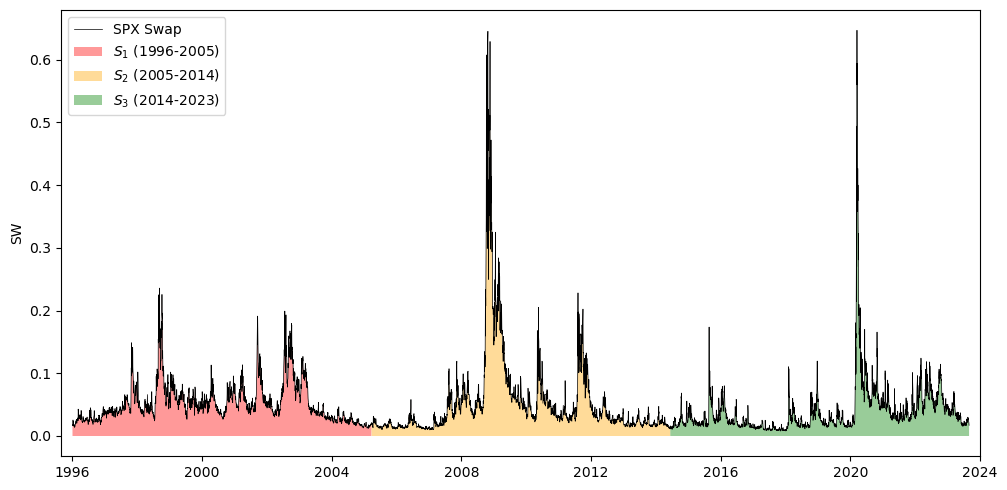

In [54]:
import matplotlib.pyplot as plt

# name map for periods
period_names = {1: "$S_1$ (1996-2005)", 2: "$S_2$ (2005-2014)", 3: "$S_3$ (2014-2023)"}
# colour map for periods
colours      = {1: 'red',      2: 'orange',      3: 'green'}

fig, ax = plt.subplots(figsize=(10, 5))

# plot the SW series
ax.plot(spx_sw.index, spx_sw['SW_0_30'], color='black', label='SPX Swap', lw=0.5)

# fill under curve by period with named labels
for period, colour in colours.items():
    mask = spx_sw['period'] == period
    ax.fill_between(
        spx_sw.index,
        spx_sw['SW_0_30'],
        where=mask,
        color=colour,
        alpha=0.4,
        interpolate=True,
        edgecolor='none',
        linewidth=0,
        label=period_names[period],
    )

ax.set_ylabel('SW')
ax.legend(loc='upper left')
plt.tight_layout()
ax.set_xlim(
    pd.Timestamp("1995-09-01"),
    pd.Timestamp("2024-01-01")
)
plt.savefig("figures/Analysis/Period/SW_time_period.pdf")
plt.show()